# 😴 SleepSense — Prediksi Gangguan Tidur
**Proyek EAS | Mata Kuliah Pembelajaran Mesin | Semester Genap 2025/2026**

Sistem prediksi gangguan tidur (Insomnia / Sleep Apnea / Tidak Ada) berdasarkan gaya hidup, menggunakan Random Forest, Decision Tree, KNN, dan XGBoost.

---
### 📋 Cara Menjalankan:
1. **Download dataset dulu:** [kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset](https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset)
2. **Runtime → Run All**
3. Di **Cell 2**, upload file `Sleep_health_and_lifestyle_dataset.csv` yang sudah didownload
4. Tunggu training selesai (~1-2 menit)
5. Klik **link ngrok** yang muncul di cell terakhir


In [1]:
# ╔══════════════════════════════════════════╗
# ║  CELL 1 – Install Library               ║
# ╚══════════════════════════════════════════╝
!pip install streamlit scikit-learn pandas numpy plotly joblib pyngrok xgboost -q
print("✅ Semua library berhasil diinstall!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 113.9 MB/s eta 0:00:00
✅ Semua library berhasil diinstall!


In [2]:
# ╔══════════════════════════════════════════╗
# ║  CELL 2 – Upload Dataset                ║
# ╚══════════════════════════════════════════╝
from google.colab import files
import os, pandas as pd

os.makedirs('sleep/data',  exist_ok=True)
os.makedirs('sleep/model', exist_ok=True)

print("📂 Silakan upload file CSV dataset Sleep Health...")
print("   (/content/Sleep_health_and_lifestyle_dataset.csv)")
uploaded = files.upload()

csv_name = list(uploaded.keys())[0]
df = pd.read_csv(csv_name)
df.to_csv('sleep/data/sleep_data.csv', index=False)

print(f"\n✅ Dataset dimuat: {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"\nKolom: {list(df.columns)}")
df.head()


📂 Silakan upload file CSV dataset Sleep Health...
   (/content/Sleep_health_and_lifestyle_dataset.csv)


Saving Sleep_health_and_lifestyle_dataset.csv to Sleep_health_and_lifestyle_dataset (1).csv

✅ Dataset dimuat: 374 baris, 13 kolom

Kolom: ['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


📊 INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB
None

M

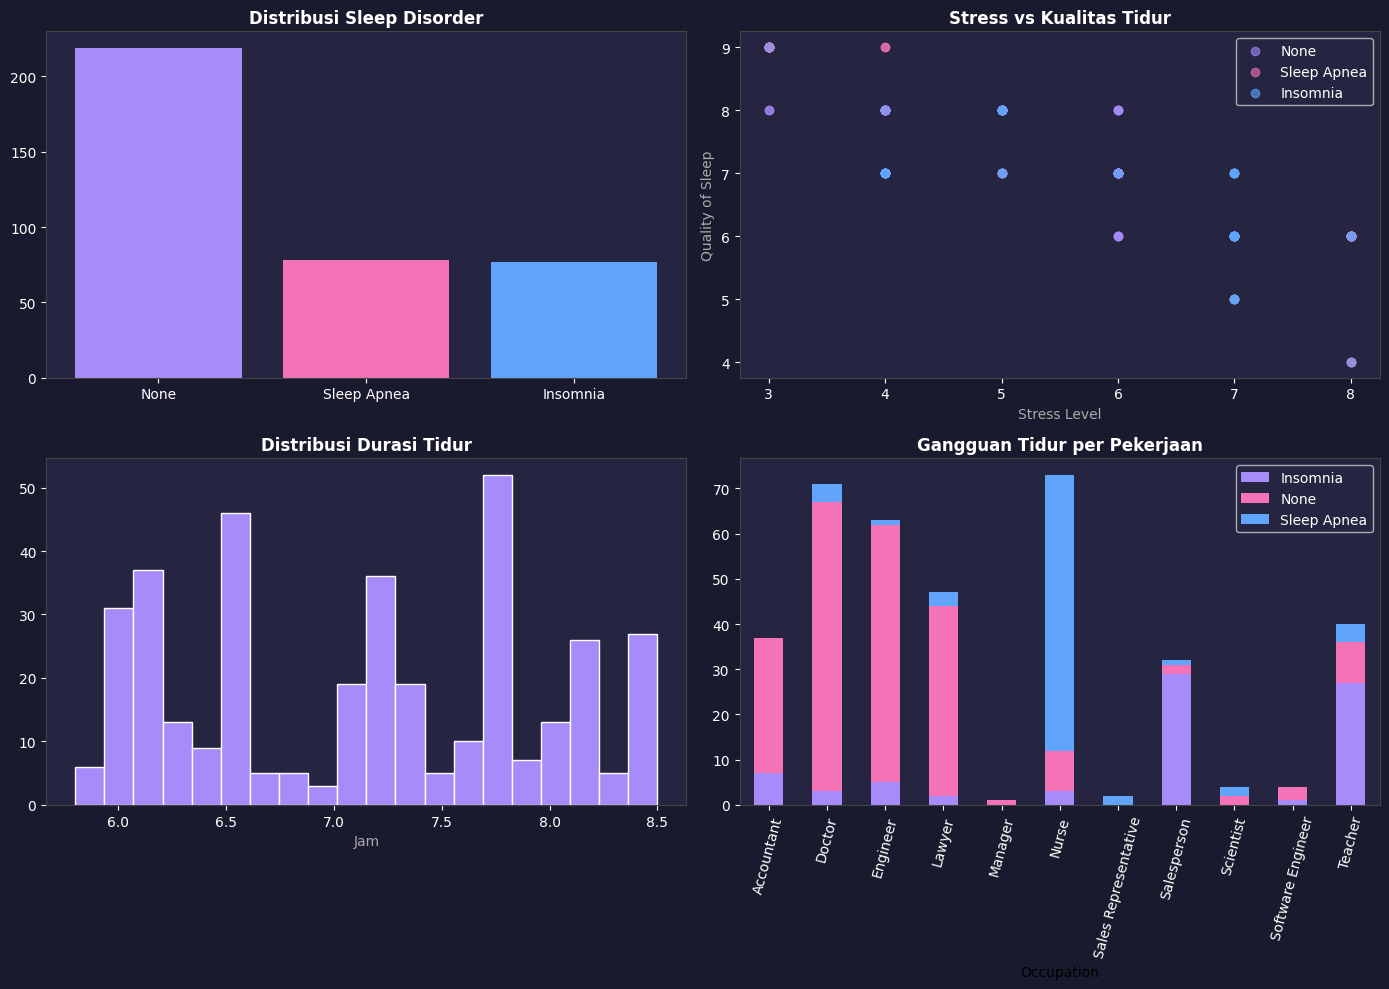


✅ EDA selesai!


In [3]:
# ╔══════════════════════════════════════════╗
# ║  CELL 3 – Eksplorasi Data (EDA)         ║
# ╚══════════════════════════════════════════╝
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('sleep/data/sleep_data.csv')

print("=" * 55)
print("📊 INFO DATASET")
print("=" * 55)
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

# Fillna untuk Sleep Disorder (NaN = tidak ada gangguan)
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

print("\nDistribusi target (Sleep Disorder):")
print(df['Sleep Disorder'].value_counts())

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#1a1a2e')
COLORS = ['#a78bfa','#f472b6','#60a5fa','#34d399','#fbbf24']

for ax in axes.flat:
    ax.set_facecolor('#252541')
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_color('#444')

# 1. Distribusi target
vc = df['Sleep Disorder'].value_counts()
axes[0,0].bar(vc.index, vc.values, color=COLORS[:len(vc)])
axes[0,0].set_title('Distribusi Sleep Disorder', color='white', fontweight='bold')

# 2. Stress vs Sleep Quality
for i, disorder in enumerate(df['Sleep Disorder'].unique()):
    sub = df[df['Sleep Disorder']==disorder]
    axes[0,1].scatter(sub['Stress Level'], sub['Quality of Sleep'],
                      label=disorder, alpha=0.6, color=COLORS[i])
axes[0,1].set_xlabel('Stress Level', color='#aaa')
axes[0,1].set_ylabel('Quality of Sleep', color='#aaa')
axes[0,1].set_title('Stress vs Kualitas Tidur', color='white', fontweight='bold')
axes[0,1].legend(facecolor='#252541', labelcolor='white')

# 3. Sleep Duration distribution
axes[1,0].hist(df['Sleep Duration'], bins=20, color='#a78bfa', edgecolor='white')
axes[1,0].set_title('Distribusi Durasi Tidur', color='white', fontweight='bold')
axes[1,0].set_xlabel('Jam', color='#aaa')

# 4. Occupation vs Disorder
occ_disorder = pd.crosstab(df['Occupation'], df['Sleep Disorder'])
occ_disorder.plot(kind='bar', stacked=True, ax=axes[1,1],
                  color=COLORS[:len(df['Sleep Disorder'].unique())])
axes[1,1].set_title('Gangguan Tidur per Pekerjaan', color='white', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=75, colors='white')
axes[1,1].legend(facecolor='#252541', labelcolor='white')

plt.tight_layout()
plt.savefig('sleep/data/eda.png', dpi=120, facecolor='#1a1a2e', bbox_inches='tight')
plt.show()
print("\n✅ EDA selesai!")


In [4]:
# ╔══════════════════════════════════════════╗
# ║  CELL 4 – Preprocessing & Training      ║
# ╚══════════════════════════════════════════╝
import pandas as pd, numpy as np, joblib, json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv('sleep/data/sleep_data.csv')
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

# Split blood pressure jadi systolic & diastolic
if 'Blood Pressure' in df.columns:
    bp_split = df['Blood Pressure'].str.split('/', expand=True)
    df['BP_Systolic']  = bp_split[0].astype(float)
    df['BP_Diastolic'] = bp_split[1].astype(float)
    df = df.drop('Blood Pressure', axis=1)

if 'Person ID' in df.columns:
    df = df.drop('Person ID', axis=1)

# Encode categorical
cat_cols = ['Gender', 'Occupation', 'BMI Category']
encoders = {}
for col in cat_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        encoders[col] = le

# Encode target
target_le = LabelEncoder()
y = target_le.fit_transform(df['Sleep Disorder'])
X = df.drop('Sleep Disorder', axis=1)

FEATURE_COLS = X.columns.tolist()
print(f"Fitur yang digunakan: {FEATURE_COLS}")
print(f"Target classes: {target_le.classes_}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

# ── Training semua model ──
models = {
    'Decision Tree':  DecisionTreeClassifier(max_depth=8, random_state=42),
    'KNN':             KNeighborsClassifier(n_neighbors=5),
    'Random Forest':   RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost':         XGBClassifier(n_estimators=150, random_state=42, eval_metric='mlogloss'),
}

results = {}
for name, clf in models.items():
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    acc  = accuracy_score(y_test, pred)
    cm   = confusion_matrix(y_test, pred)
    results[name] = {'model': clf, 'accuracy': acc, 'cm': cm.tolist()}
    print(f"{name:18s}  Accuracy: {acc*100:.2f}%")

print("\nClassification Report (model terbaik):")
best_name = max(results, key=lambda x: results[x]['accuracy'])
best_pred = results[best_name]['model'].predict(X_test)
print(classification_report(y_test, best_pred, target_names=target_le.classes_))

# ── Save semua ──
joblib.dump(scaler,     'sleep/model/scaler.pkl')
joblib.dump(encoders,   'sleep/model/encoders.pkl')
joblib.dump(target_le,  'sleep/model/target_encoder.pkl')
joblib.dump(FEATURE_COLS, 'sleep/model/feature_cols.pkl')

for name, r in results.items():
    fname = name.lower().replace(' ', '_')
    joblib.dump(r['model'], f'sleep/model/{fname}_model.pkl')

results_summary = {name: {'accuracy': r['accuracy'], 'cm': r['cm']} for name, r in results.items()}
with open('sleep/model/results.json', 'w') as f:
    json.dump(results_summary, f)

# Feature importance dari RF
fi = dict(zip(FEATURE_COLS, results['Random Forest']['model'].feature_importances_.tolist()))
with open('sleep/model/feature_importance.json', 'w') as f:
    json.dump(fi, f)

print(f"\n✅ Semua model tersimpan! Terbaik: {best_name} ({results[best_name]['accuracy']*100:.2f}%)")


Fitur yang digunakan: ['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'BP_Systolic', 'BP_Diastolic']
Target classes: ['Insomnia' 'None' 'Sleep Apnea']

Train: 299 | Test: 75
Decision Tree       Accuracy: 93.33%
KNN                 Accuracy: 93.33%
Random Forest       Accuracy: 96.00%
XGBoost             Accuracy: 96.00%

Classification Report (model terbaik):
              precision    recall  f1-score   support

    Insomnia       0.88      0.93      0.90        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.94      0.94      0.94        16

    accuracy                           0.96        75
   macro avg       0.94      0.95      0.94        75
weighted avg       0.96      0.96      0.96        75


✅ Semua model tersimpan! Terbaik: Random Forest (96.00%)


In [5]:
# ╔══════════════════════════════════════════╗
# ║  CELL 5 – Buat File app.py              ║
# ╚══════════════════════════════════════════╝
app_code = 'import streamlit as st\nimport pandas as pd, numpy as np, joblib, json, os\nimport plotly.express as px\nimport plotly.graph_objects as go\n\nst.set_page_config(\n    page_title="😴 SleepSense – Prediksi Gangguan Tidur",\n    page_icon="😴", layout="wide", initial_sidebar_state="expanded"\n)\n\nst.markdown("""\n<style>\n@import url(\'https://fonts.googleapis.com/css2?family=Quicksand:wght@400;500;600;700&display=swap\');\nhtml, body, [class*="css"] { font-family: \'Quicksand\', sans-serif; }\n.stApp { background: linear-gradient(180deg, #1a1a2e 0%, #16213e 100%); }\n\n.hero {\n    background: linear-gradient(135deg, #4c1d95 0%, #6d28d9 50%, #a855f7 100%);\n    border-radius: 22px; padding: 2.5rem 2rem; margin-bottom: 1.5rem;\n    box-shadow: 0 0 40px rgba(168,85,247,0.25);\n}\n.hero h1 { font-size: 2.4rem; font-weight: 700; margin: 0; color: white; }\n.hero p  { font-size: 1rem; color: #e9d5ff; margin: .5rem 0 0; }\n\n.card {\n    background: #20203a; border-radius: 18px; padding: 1.6rem;\n    border: 1px solid rgba(168,85,247,0.15);\n    box-shadow: 0 4px 20px rgba(0,0,0,0.3); margin-bottom: 1rem;\n}\n.card h3 { font-weight: 700; margin: 0 0 1rem; font-size: 1.05rem; color: #c4b5fd; }\n\n.metric-box {\n    background: linear-gradient(135deg, #20203a, #2a2a4a);\n    border-radius: 16px; padding: 1.3rem; text-align: center;\n    border: 1px solid rgba(168,85,247,0.2);\n}\n.metric-box .val { font-size: 1.8rem; font-weight: 700; color: #c4b5fd; }\n.metric-box .lbl { font-size: .72rem; color: #9ca3af; font-weight: 600;\n                   text-transform: uppercase; letter-spacing: 1px; margin-top: .3rem; }\n\n.result-good {\n    background: linear-gradient(135deg, #064e3b, #047857);\n    border: 2px solid #34d399; border-radius: 18px; padding: 2rem; text-align: center;\n    box-shadow: 0 0 30px rgba(52,211,153,0.2);\n}\n.result-warn {\n    background: linear-gradient(135deg, #7c2d12, #c2410c);\n    border: 2px solid #fb923c; border-radius: 18px; padding: 2rem; text-align: center;\n    box-shadow: 0 0 30px rgba(251,146,60,0.2);\n}\n.result-icon  { font-size: 4rem; }\n.result-label { font-size: 1.8rem; font-weight: 700; color: white; }\n.result-sub   { font-size: .9rem; color: #e5e7eb; margin-top: .3rem; }\n\ndiv[data-testid="stSidebar"] {\n    background: linear-gradient(180deg, #1a1a2e 0%, #4c1d95 100%) !important;\n}\ndiv[data-testid="stSidebar"] p,\ndiv[data-testid="stSidebar"] span,\ndiv[data-testid="stSidebar"] label { color: #e9d5ff !important; }\ndiv[data-testid="stSidebar"] h2 { color: #c4b5fd !important; }\n\ndiv[data-testid="stButton"] > button {\n    background: linear-gradient(135deg, #7c3aed, #c026d3) !important;\n    color: white !important; border: none !important;\n    border-radius: 12px !important; font-weight: 700 !important;\n    width: 100% !important; font-size: 1rem !important; padding: .7rem !important;\n}\n\np, span, li { color: #e5e7eb !important; }\nh1, h2, h3, h4 { color: #f3f4f6 !important; }\n.stTabs [data-baseweb="tab"] { color: #9ca3af !important; }\n.stTabs [aria-selected="true"] { color: #c4b5fd !important; border-bottom-color: #c4b5fd !important; }\n</style>\n""", unsafe_allow_html=True)\n\nBASE = os.path.dirname(__file__)\n\n@st.cache_data\ndef load_data():\n    return pd.read_csv(os.path.join(BASE, \'data\', \'sleep_data.csv\'))\n\n@st.cache_data\ndef load_results():\n    with open(os.path.join(BASE, \'model\', \'results.json\')) as f:\n        return json.load(f)\n\n@st.cache_data\ndef load_fi():\n    with open(os.path.join(BASE, \'model\', \'feature_importance.json\')) as f:\n        return json.load(f)\n\n@st.cache_resource\ndef load_models():\n    scaler  = joblib.load(os.path.join(BASE, \'model\', \'scaler.pkl\'))\n    enc     = joblib.load(os.path.join(BASE, \'model\', \'encoders.pkl\'))\n    tgt_enc = joblib.load(os.path.join(BASE, \'model\', \'target_encoder.pkl\'))\n    fcols   = joblib.load(os.path.join(BASE, \'model\', \'feature_cols.pkl\'))\n    models  = {}\n    for name in [\'Decision Tree\',\'KNN\',\'Random Forest\',\'XGBoost\']:\n        fname = name.lower().replace(\' \', \'_\')\n        models[name] = joblib.load(os.path.join(BASE, \'model\', f\'{fname}_model.pkl\'))\n    return scaler, enc, tgt_enc, fcols, models\n\ndf = load_data()\ndf[\'Sleep Disorder\'] = df[\'Sleep Disorder\'].fillna(\'None\')\nresults = load_results()\nfeat_importance = load_fi()\nscaler, encoders, target_le, FEATURE_COLS, models = load_models()\n\nPLOT_THEME = dict(plot_bgcolor=\'#20203a\', paper_bgcolor=\'#20203a\',\n                  font_color=\'#e5e7eb\', margin=dict(t=30,b=10,l=10,r=10))\nDISORDER_COLORS = {\'None\': \'#34d399\', \'Insomnia\': \'#fb923c\', \'Sleep Apnea\': \'#f87171\'}\nDISORDER_EMOJI  = {\'None\': \'😴\', \'Insomnia\': \'😵\', \'Sleep Apnea\': \'😮\u200d💨\'}\n\nwith st.sidebar:\n    st.markdown("## 😴 SleepSense")\n    st.markdown("---")\n    page = st.radio("Navigasi", [\n        "🏠 Beranda", "📊 Analisis Data", "🤖 Perbandingan Model", "🔍 Cek Kesehatan Tidur"\n    ], label_visibility="collapsed")\n    st.markdown("---")\n    st.markdown("**Kelompok EAS**")\n    st.markdown("Mata Kuliah: Pembelajaran Mesin")\n    st.markdown("Semester Genap 2025/2026")\n\n# ════════════════════════════════════════\n# BERANDA\n# ════════════════════════════════════════\nif page == "🏠 Beranda":\n    st.markdown("""<div class="hero">\n        <h1>😴 SleepSense</h1>\n        <p>Sistem Prediksi Gangguan Tidur Berbasis Machine Learning · Gaya Hidup Sehat untuk Semua</p>\n    </div>""", unsafe_allow_html=True)\n\n    best_model = max(results, key=lambda x: results[x][\'accuracy\'])\n    c1,c2,c3,c4 = st.columns(4)\n    for col,(val,lbl) in zip([c1,c2,c3,c4],[\n        (str(len(df)), "Total Data"),\n        (str(df[\'Sleep Disorder\'].nunique()), "Kategori Gangguan"),\n        (f"{results[best_model][\'accuracy\']*100:.1f}%", "Akurasi Terbaik"),\n        ("4", "Algoritma ML"),\n    ]):\n        col.markdown(f\'<div class="metric-box"><div class="val">{val}</div><div class="lbl">{lbl}</div></div>\', unsafe_allow_html=True)\n\n    st.markdown("<br>", unsafe_allow_html=True)\n    ca, cb = st.columns(2)\n    with ca:\n        st.markdown(\'<div class="card"><h3>📌 Tentang Proyek</h3>\', unsafe_allow_html=True)\n        st.markdown("""\n**SleepSense** membantu mendeteksi risiko gangguan tidur berdasarkan gaya hidup sehari-hari.\n\n**Fitur yang dianalisis:**\n- 💼 Pekerjaan & usia\n- 😰 Level stress\n- 🏃 Aktivitas fisik & langkah harian\n- ⏰ Durasi & kualitas tidur\n- ⚖️ BMI & tekanan darah\n\n**Output:** None / Insomnia / Sleep Apnea\n        """)\n        st.markdown(\'</div>\', unsafe_allow_html=True)\n    with cb:\n        vc = df[\'Sleep Disorder\'].value_counts()\n        fig = go.Figure(go.Pie(\n            labels=vc.index, values=vc.values, hole=.55,\n            marker_colors=[DISORDER_COLORS.get(x,\'#888\') for x in vc.index],\n        ))\n        fig.update_layout(title=\'Distribusi Gangguan Tidur\', **PLOT_THEME, height=320,\n                          legend=dict(font_color=\'#ccc\'))\n        st.plotly_chart(fig, use_container_width=True)\n\n    st.markdown(\'<div class="card"><h3>📋 Preview Dataset</h3>\', unsafe_allow_html=True)\n    st.dataframe(df.head(10), use_container_width=True)\n    st.markdown(\'</div>\', unsafe_allow_html=True)\n\n# ════════════════════════════════════════\n# ANALISIS DATA\n# ════════════════════════════════════════\nelif page == "📊 Analisis Data":\n    st.markdown("""<div class="hero">\n        <h1>📊 Analisis Data</h1>\n        <p>Eksplorasi pola gangguan tidur berdasarkan gaya hidup</p>\n    </div>""", unsafe_allow_html=True)\n\n    tab1, tab2, tab3 = st.tabs(["📈 Distribusi Fitur", "🔗 Korelasi", "💼 Per Pekerjaan"])\n\n    with tab1:\n        feat = st.selectbox("Pilih Fitur Numerik",\n                            [\'Age\',\'Sleep Duration\',\'Quality of Sleep\',\'Physical Activity Level\',\n                             \'Stress Level\',\'Heart Rate\',\'Daily Steps\'])\n        fig = go.Figure()\n        for disorder in df[\'Sleep Disorder\'].unique():\n            sub = df[df[\'Sleep Disorder\']==disorder]\n            fig.add_trace(go.Box(y=sub[feat], name=disorder,\n                                 marker_color=DISORDER_COLORS.get(disorder,\'#888\')))\n        fig.update_layout(title=f\'{feat} berdasarkan Gangguan Tidur\', **PLOT_THEME, height=420)\n        st.plotly_chart(fig, use_container_width=True)\n\n    with tab2:\n        num_cols = [\'Age\',\'Sleep Duration\',\'Quality of Sleep\',\'Physical Activity Level\',\n                   \'Stress Level\',\'Heart Rate\',\'Daily Steps\']\n        corr = df[num_cols].corr()\n        fig = px.imshow(corr, text_auto=".2f", color_continuous_scale=\'Purples\', height=480)\n        fig.update_layout(**PLOT_THEME, title=\'Heatmap Korelasi Antar Fitur\')\n        st.plotly_chart(fig, use_container_width=True)\n\n    with tab3:\n        occ_disorder = pd.crosstab(df[\'Occupation\'], df[\'Sleep Disorder\'])\n        fig = go.Figure()\n        for disorder in df[\'Sleep Disorder\'].unique():\n            if disorder in occ_disorder.columns:\n                fig.add_trace(go.Bar(name=disorder, x=occ_disorder.index,\n                                     y=occ_disorder[disorder],\n                                     marker_color=DISORDER_COLORS.get(disorder,\'#888\')))\n        fig.update_layout(barmode=\'stack\', title=\'Gangguan Tidur per Pekerjaan\',\n                          xaxis_tickangle=-40, **PLOT_THEME, height=450)\n        st.plotly_chart(fig, use_container_width=True)\n\n# ════════════════════════════════════════\n# PERBANDINGAN MODEL\n# ════════════════════════════════════════\nelif page == "🤖 Perbandingan Model":\n    st.markdown("""<div class="hero">\n        <h1>🤖 Perbandingan Model</h1>\n        <p>Evaluasi Decision Tree, KNN, Random Forest, dan XGBoost</p>\n    </div>""", unsafe_allow_html=True)\n\n    names = list(results.keys())\n    accs  = [results[n][\'accuracy\'] for n in names]\n\n    cols = st.columns(len(names))\n    for col, name, acc in zip(cols, names, accs):\n        col.markdown(f\'<div class="metric-box"><div class="lbl">{name}</div><div class="val">{acc*100:.1f}%</div></div>\', unsafe_allow_html=True)\n\n    st.markdown("<br>", unsafe_allow_html=True)\n    tab1, tab2, tab3 = st.tabs(["📈 Akurasi", "🎯 Confusion Matrix", "💡 Feature Importance"])\n\n    with tab1:\n        fig = go.Figure(go.Bar(\n            x=names, y=[a*100 for a in accs],\n            marker_color=[\'#a78bfa\',\'#f472b6\',\'#60a5fa\',\'#34d399\'],\n            text=[f"{a*100:.2f}%" for a in accs], textposition=\'outside\', textfont_color=\'white\',\n        ))\n        fig.update_layout(title=\'Akurasi 4 Model\', yaxis=dict(range=[0,110]), **PLOT_THEME, height=400)\n        st.plotly_chart(fig, use_container_width=True)\n        best = max(results, key=lambda x: results[x][\'accuracy\'])\n        st.success(f"🏆 Model terbaik: **{best}** dengan akurasi **{results[best][\'accuracy\']*100:.2f}%**")\n\n    with tab2:\n        model_sel = st.selectbox("Pilih Model", names)\n        cm = np.array(results[model_sel][\'cm\'])\n        labels = target_le.classes_.tolist()\n        fig = px.imshow(cm, text_auto=True, x=labels, y=labels,\n                        labels=dict(x="Prediksi", y="Aktual"),\n                        color_continuous_scale=\'Purples\', height=420)\n        fig.update_layout(**PLOT_THEME, title=f\'Confusion Matrix – {model_sel}\')\n        st.plotly_chart(fig, use_container_width=True)\n\n    with tab3:\n        fi_sorted = dict(sorted(feat_importance.items(), key=lambda x: x[1]))\n        fig = go.Figure(go.Bar(\n            x=list(fi_sorted.values()), y=list(fi_sorted.keys()), orientation=\'h\',\n            marker_color=\'#a78bfa\',\n        ))\n        fig.update_layout(title=\'Feature Importance (Random Forest)\', **PLOT_THEME, height=420)\n        st.plotly_chart(fig, use_container_width=True)\n\n# ════════════════════════════════════════\n# PREDIKSI\n# ════════════════════════════════════════\nelif page == "🔍 Cek Kesehatan Tidur":\n    st.markdown("""<div class="hero">\n        <h1>🔍 Cek Kesehatan Tidur</h1>\n        <p>Isi data diri kamu untuk memeriksa risiko gangguan tidur</p>\n    </div>""", unsafe_allow_html=True)\n\n    model_sel = st.selectbox("Pilih Model", list(models.keys()))\n    clf = models[model_sel]\n\n    st.markdown(\'<div class="card"><h3>👤 Data Diri</h3>\', unsafe_allow_html=True)\n    c1, c2, c3 = st.columns(3)\n    gender = c1.selectbox("Gender", encoders[\'Gender\'].classes_)\n    age    = c2.slider("Usia", 18, 70, 28)\n    occ_options = encoders[\'Occupation\'].classes_\n    occupation = c3.selectbox("Pekerjaan", occ_options)\n    st.markdown(\'</div>\', unsafe_allow_html=True)\n\n    st.markdown(\'<div class="card"><h3>😴 Pola Tidur</h3>\', unsafe_allow_html=True)\n    c4, c5 = st.columns(2)\n    sleep_dur = c4.slider("Durasi Tidur (jam)", 4.0, 10.0, 7.0, step=0.1)\n    sleep_qual = c5.slider("Kualitas Tidur (1-10)", 1, 10, 7)\n    st.markdown(\'</div>\', unsafe_allow_html=True)\n\n    st.markdown(\'<div class="card"><h3>🏃 Gaya Hidup & Kesehatan</h3>\', unsafe_allow_html=True)\n    c6, c7, c8 = st.columns(3)\n    activity = c6.slider("Aktivitas Fisik (menit/hari)", 0, 120, 45)\n    stress   = c7.slider("Level Stress (1-10)", 1, 10, 5)\n    steps    = c8.number_input("Langkah Harian", 1000, 20000, 6000, step=500)\n\n    c9, c10, c11 = st.columns(3)\n    bmi_cat  = c9.selectbox("Kategori BMI", encoders[\'BMI Category\'].classes_)\n    hr       = c10.slider("Detak Jantung (bpm)", 50, 110, 72)\n    bp_sys   = c11.number_input("Tekanan Darah Sistolik", 90, 180, 120)\n    bp_dia   = st.number_input("Tekanan Darah Diastolik", 60, 120, 80)\n    st.markdown(\'</div>\', unsafe_allow_html=True)\n\n    if st.button("🔍 Analisis Kesehatan Tidur Saya"):\n        input_dict = {\n            \'Gender\': encoders[\'Gender\'].transform([gender])[0],\n            \'Age\': age,\n            \'Occupation\': encoders[\'Occupation\'].transform([occupation])[0],\n            \'Sleep Duration\': sleep_dur,\n            \'Quality of Sleep\': sleep_qual,\n            \'Physical Activity Level\': activity,\n            \'Stress Level\': stress,\n            \'BMI Category\': encoders[\'BMI Category\'].transform([bmi_cat])[0],\n            \'Heart Rate\': hr,\n            \'Daily Steps\': steps,\n            \'BP_Systolic\': bp_sys,\n            \'BP_Diastolic\': bp_dia,\n        }\n        input_df = pd.DataFrame([input_dict])[FEATURE_COLS]\n        input_scaled = scaler.transform(input_df)\n\n        pred_idx = clf.predict(input_scaled)[0]\n        pred_label = target_le.inverse_transform([pred_idx])[0]\n        proba = clf.predict_proba(input_scaled)[0] if hasattr(clf,\'predict_proba\') else None\n\n        box_class = "result-good" if pred_label == "None" else "result-warn"\n        emoji = DISORDER_EMOJI.get(pred_label, "😴")\n\n        if pred_label == "None":\n            sub_text = "Pola tidurmu terlihat sehat! Pertahankan gaya hidup ini 👍"\n        elif pred_label == "Insomnia":\n            sub_text = "Terdeteksi indikasi insomnia. Pertimbangkan kelola stress & rutinitas tidur."\n        else:\n            sub_text = "Terdeteksi indikasi sleep apnea. Disarankan konsultasi ke dokter spesialis tidur."\n\n        st.markdown(f"""\n        <div class="{box_class}">\n            <div class="result-icon">{emoji}</div>\n            <div class="result-label">{pred_label}</div>\n            <div class="result-sub">{sub_text}</div>\n        </div>""", unsafe_allow_html=True)\n\n        if proba is not None:\n            st.markdown("<br>", unsafe_allow_html=True)\n            st.markdown(\'<div class="card"><h3>📊 Probabilitas Tiap Kategori</h3>\', unsafe_allow_html=True)\n            classes = target_le.classes_\n            fig = go.Figure(go.Bar(\n                x=classes, y=[p*100 for p in proba],\n                marker_color=[DISORDER_COLORS.get(c,\'#888\') for c in classes],\n                text=[f"{p*100:.1f}%" for p in proba], textposition=\'outside\', textfont_color=\'white\',\n            ))\n            fig.update_layout(yaxis=dict(range=[0,115]), **PLOT_THEME, height=320)\n            st.plotly_chart(fig, use_container_width=True)\n            st.markdown(\'</div>\', unsafe_allow_html=True)\n\n        st.info("⚠️ **Disclaimer:** Hasil ini hanya prediksi berbasis data dan bukan diagnosis medis. Konsultasikan ke dokter untuk pemeriksaan lebih lanjut.")\n'

with open('sleep/app.py', 'w') as f:
    f.write(app_code)
print("✅ File sleep/app.py berhasil dibuat!")


✅ File sleep/app.py berhasil dibuat!


In [10]:
# ╔══════════════════════════════════════════════════════╗
# ║  CELL 6 – Jalankan Dashboard (Streamlit + ngrok)     ║
# ╚══════════════════════════════════════════════════════╝
import subprocess, time
from pyngrok import ngrok

# Jika punya ngrok authtoken, uncomment baris ini dan GANTI "YOUR_AUTHTOKEN_HERE" dengan tokenmu:
ngrok.set_auth_token("3EExmRIay0YrynaDbWofpd40Fb7_2LYC221WEKsLoPUnPWF1P") # <--- GANTI DENGAN AUTH TOKEN ASLI ANDA

subprocess.run(['pkill', '-f', 'streamlit'], capture_output=True)
time.sleep(2)

proc = subprocess.Popen(
    ['streamlit', 'run', 'sleep/app.py',
     '--server.port=8501', '--server.headless=true'],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
time.sleep(5)

public_url = ngrok.connect(8501)
print("=" * 55)
print("✅ SLEEPSENSE DASHBOARD BERHASIL DIJALANKAN!")
print(f"\n🌐 Buka di browser:")
print(f"   {public_url}")
print("\n⚠️  Link aktif selama sesi Colab berjalan.")
print("=" * 55)

✅ SLEEPSENSE DASHBOARD BERHASIL DIJALANKAN!

🌐 Buka di browser:
   NgrokTunnel: "https://unexpired-euphemism-spindle.ngrok-free.dev" -> "http://localhost:8501"

⚠️  Link aktif selama sesi Colab berjalan.
